# Case Study

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Sample dataset (replace with your real data)
data = {
    "marketing_spend": [10, 20, 30, 40, 50, 60, 70],
    "price": [100, 98, 95, 93, 90, 88, 85],
    "distributors":[5, 7, 9, 11, 13, 15, 17],
    "sales":[200, 250, 300, 370, 420, 480, 550]
}

df = pd.DataFrame(data)

X = df[["marketing_spend", "price", "distributors"]]
y = df["sales"]

model = LinearRegression()
model.fit(X, y)

print("Model Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Model Coefficients: [ 5.19688645 -1.66666667  1.03937729]
Intercept: 302.35805860805084


```bash
Intercept: 302.36
Coefficients:
[ 5.20  → marketing_spend
 -1.67  → price
  1.04  → distributors ]
-----------------------------
1. Final Model Equation
Your model is:
Sales=302.36 + 5.20(Marketing) −1.67(Price) +1.04(Distributors)
------------------------------------------------------------------
2. Business Interpretation (Core Insight)
🔹 Intercept = 302.36
👉 Base sales level

Meaning:
Even if:

    marketing = 0
    price = 0
    distributors = 0
👉 Sales ≈ 302 units

💡 Think of it as:

    brand strength
    existing demand
    market baseline
------------------------------------------------------------------
🔹 Marketing = +5.20 (Strong Positive)
    👉 For every +1 unit marketing:
    👉 Sales increase by 5.2 units
💡 Insight:
Marketing is a strong growth driver
High ROI potential

------------------------------------------------------------------

🔹 Price = -1.67 (Negative Impact)
👉 For every +1 unit price:
👉 Sales decrease by 1.67 units

💡 Insight:

Customers are price sensitive
Increasing price reduces demand
------------------------------------------------------------------
🔹 Distributors = +1.04 (Positive)

👉 For every +1 distributor:
👉 Sales increase by 1.04 units

💡 Insight:

Distribution helps, but impact is moderate
Expansion still beneficial
------------------------------------------------------------------

📈 3. Feature Importance (Ranking)

| Feature      | Impact       |
| ------------ | ------------ |
| Marketing    | ⭐⭐⭐⭐⭐ (5.20) |
| Price        | ⭐⭐⭐ (-1.67)  |
| Distributors | ⭐⭐ (1.04)    |

👉 Marketing is the dominant driver

# 📉 CASE 1: Sales Drop Analysis

👉 Use this to detect when drop started

In [2]:
# Compare periods (simulate)
df["sales_change"] = df["sales"].pct_change()

print(df[["sales", "sales_change"]])

   sales  sales_change
0    200           NaN
1    250      0.250000
2    300      0.200000
3    370      0.233333
4    420      0.135135
5    480      0.142857
6    550      0.145833


# 📈 CASE 2: Marketing ROI

In [ ]:
coef_marketing = model.coef_[0]  # 0 mean marketing cost consideration

print("Marketing Impact:", coef_marketing)

roi = coef_marketing / df["marketing_spend"].mean()
print("Estimated ROI:", roi)

Marketing Impact: 5.1968864468864675
Estimated ROI: 0.12992216117216168


```bash
👉 Interpretation:
Higher coefficient = stronger ROI

```bash

🧠 1. What does “Marketing Impact = 5.20” mean?

👉 From your regression:

If marketing_spend increases by 1 unit
→ sales increase by ~5.2 units
💡 Business Meaning:

Marketing is a strong driver of sales growth
---------------------------------------------
🧠 2. What is your ROI formula doing?
roi = coef_marketing / df["marketing_spend"].mean()
👉 You are calculating:

“Impact per unit ÷ average spend”
-----------------------------------------------

📉 3. What does ROI = 0.1299 mean?
👉 Roughly:
0.13 (or 13%) return per unit of average marketing spend

🧠 4. Interpret in business language

```bash
🎯 Simple explanation:

For every 1 unit of average marketing spend, you are generating about 0.13 units of additional sales efficiency

```bash
⚠️ But here’s the truth (important correction)

This ROI is:

❌ NOT a true financial ROI
✅ It’s a normalized impact metric
---------------------------------------------
🧠 5. Why it’s not true ROI
Because real ROI should be:
ROI = (Revenue - Cost) / Cost
-----------------------------------------------

But your version is:
👉 “coefficient scaled by average spend”
So it's more like:
👉 “relative effectiveness indicator”

# 💰 CASE 3: Pricing Strategy Simulation

👉 Helps decide optimal price

In [4]:
def simulate_price(price_value):
    avg_marketing = df["marketing_spend"].mean()
    avg_dist = df["distributors"].mean()
    
    pred = model.predict([[avg_marketing, price_value, avg_dist]])
    return pred[0]

for p in [85, 90, 95, 100]:
    print(f"Price {p} → Predicted Sales:", simulate_price(p))

Price 85 → Predicted Sales: 379.99999999999943
Price 90 → Predicted Sales: 371.66666666666646
Price 95 → Predicted Sales: 363.3333333333335
Price 100 → Predicted Sales: 355.00000000000057


c:\Users\User\.conda\envs\dsknowledge\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\User\.conda\envs\dsknowledge\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\User\.conda\envs\dsknowledge\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\User\.conda\envs\dsknowledge\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# 📦 CASE 4: Distributor Impact

👉 If high → invest in distribution

In [5]:
coef_dist = model.coef_[2]
print("Distributor Impact:", coef_dist)

Distributor Impact: 1.0393772893772935


# 📊 CASE 5: Forecasting

In [6]:
# Example future scenario
future = pd.DataFrame({
    "marketing_spend": [80],
    "price": [85],
    "distributors": [20]
})

prediction = model.predict(future)
print("Future Sales Prediction:", prediction[0])

Future Sales Prediction: 597.2298534798538


🧠 1. What did you actually do?

- You gave the model a new business scenario:

| Variable        | Value |
| --------------- | ----- |
| Marketing Spend | 80    |
| Price           | 85    |
| Distributors    | 20    |


🎯 2. What the model did internally

- Your model used the learned equation:

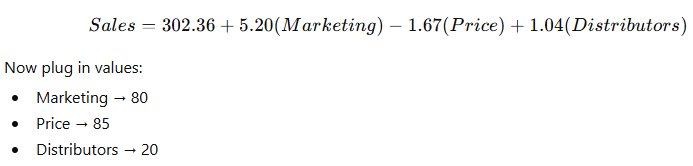

🧮 3. Rough Calculation (Intuition)

```bash
Let’s estimate:

Marketing effect → 80×5.2≈416
Price effect → 85×−1.67≈−142
Distributor effect → 20×1.04≈20.8
Base → 302

👉 Total ≈
302 + 416 − 142 + 21 ≈ ~597

✔ Matches your output

### 🧠 4. Business Interpretation

```bash

👉 If you run this strategy:

Increase marketing to 80
Keep price at 85
Expand distributors to 20

➡️ Expected sales ≈ 597 units

# 🚨 CASE 6: Model Evaluation

In [7]:
y_pred = model.predict(X)

print("R2 Score:", r2_score(y, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y, y_pred)))

R2 Score: 0.9973473473473473
RMSE: 6.004533434723081


### 🧠 1. R² Score (Goodness of Fit)

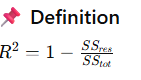

```bash
🎯 Your Result: 0.9973

👉 This means:
- 99.73% of the variation in sales is explained by your model

💡 Interpretation
1.0 → perfect model
0.0 → useless model

👉 Your model = almost perfect fit

-----------------------------------------

🧠 Business Meaning
“Sales is almost fully explained by marketing, price, and distributors”


📉 2. RMSE (Error Size)

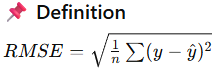

```bash
🎯 Your Result: 6.00
👉 This means:

On average, your prediction is off by ±6 sales units

💡 Interpretation

If actual sales = 500
👉 Prediction ≈ 494 to 506

### 🧠 3. Combine Both (Important)

| Metric     | Meaning                          |
| ---------- | -------------------------------- |
| R² = 0.997 | Model explains almost everything |
| RMSE = 6   | Very small prediction error      |

```bash
👉 Together:

✔ High accuracy
✔ Low error
✔ Strong predictive model

```bash
🎯 6. Simple Analogy

Think like this:

R² → “How well I understand the system”
RMSE → “How much I make mistakes”

👉 You:

Understand almost everything (99.7%)
Make small mistakes (~6 units)

```bash

🚀 7. Final CEO-Level Statement

“The model demonstrates very high explanatory power with an R² of 0.997 and low prediction error (RMSE ≈ 6 units), indicating strong performance. However, due to limited data, further validation is recommended before making strategic decisions.”

# 📈 CASE 7: Feature Importance

In [8]:
features = X.columns
importance = model.coef_

for f, i in zip(features, importance):
    print(f"{f}: {i}")

marketing_spend: 5.1968864468864675
price: -1.6666666666665921
distributors: 1.0393772893772935


# 📊 CASE 8: Scenario Simulation (Powerful)

👉 This is decision engine

In [9]:
def simulate(marketing, price, distributors):
    return model.predict([[marketing, price, distributors]])[0]

print(simulate(50, 90, 10))
print(simulate(80, 85, 20))

422.5961538461538
597.2298534798538


c:\Users\User\.conda\envs\dsknowledge\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\User\.conda\envs\dsknowledge\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### 🧠 What You Just Built

```bash
You now have:

👉 Sales Analysis System
👉 ROI Calculator
👉 Pricing Simulator
👉 Forecasting Tool
```